# Bees production 

### Setup

In [15]:
import numpy as np
import pandas as pd 
import utils
import matplotlib.pyplot as plt
import importlib
importlib.reload(utils)
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import OneHotEncoder


honey_production_df, apistox_df, bees_health_weather_dict = utils.load_bees_datasets()
honey_production_df_copy = honey_production_df.copy()
apistox_df_copy = apistox_df.copy()

 honey_production_df (1115, 9) : Done! 

 apistox_df (1035, 13) : Done! 

 Apiary_Information.csv (13, 4) : Done!
 HCC_Inspections.csv (2404, 11) : Done!
 Hive_Information.csv (188, 3) : Done!
 Hourly_Weather.csv (3672, 15) : Done!
 Weather_Observations.csv (1776, 4) : Done!
 Weather_Stations.csv (3, 3) : Done!

Datasets collection completed.


## Part 1: Honey production 

In [9]:
honey_production_df = honey_production_df_copy.copy()

#cleaning the dataset
honey_production_df.drop(columns=["Unnamed: 0"], inplace=True)
for state in honey_production_df.state.unique():
    state_production = honey_production_df[honey_production_df.state == state]
    #keeping states that have data for all the 27 years from 1995 to 2021
    if len(state_production) < 27:
        honey_production_df.drop(state_production.index, inplace=True)

n_states = honey_production_df.state.nunique()
utils.EDA(honey_production_df, head = n_states) #to show the first data for all the considered states

honey_production_df_copy = honey_production_df.copy()

##-------------- INFO ------------------------------##

<class 'pandas.core.frame.DataFrame'>
Index: 1026 entries, 0 to 1114
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   state                1026 non-null   object 
 1   colonies_number      1026 non-null   int64  
 2   yield_per_colony     1026 non-null   int64  
 3   production           1026 non-null   int64  
 4   stocks               1026 non-null   int64  
 5   average_price        1026 non-null   float64
 6   value_of_production  1026 non-null   int64  
 7   year                 1026 non-null   int64  
dtypes: float64(1), int64(6), object(1)
memory usage: 72.1+ KB


##-------------- DESCRIBE --------------------------##
        colonies_number  yield_per_colony    production        stocks  \
count      1026.000000       1026.000000  1.026000e+03  1.026000e+03   
mean      67181.286550         60.496101  3.071741e+06  1.265299e+06   
std   

### Production Analysis 

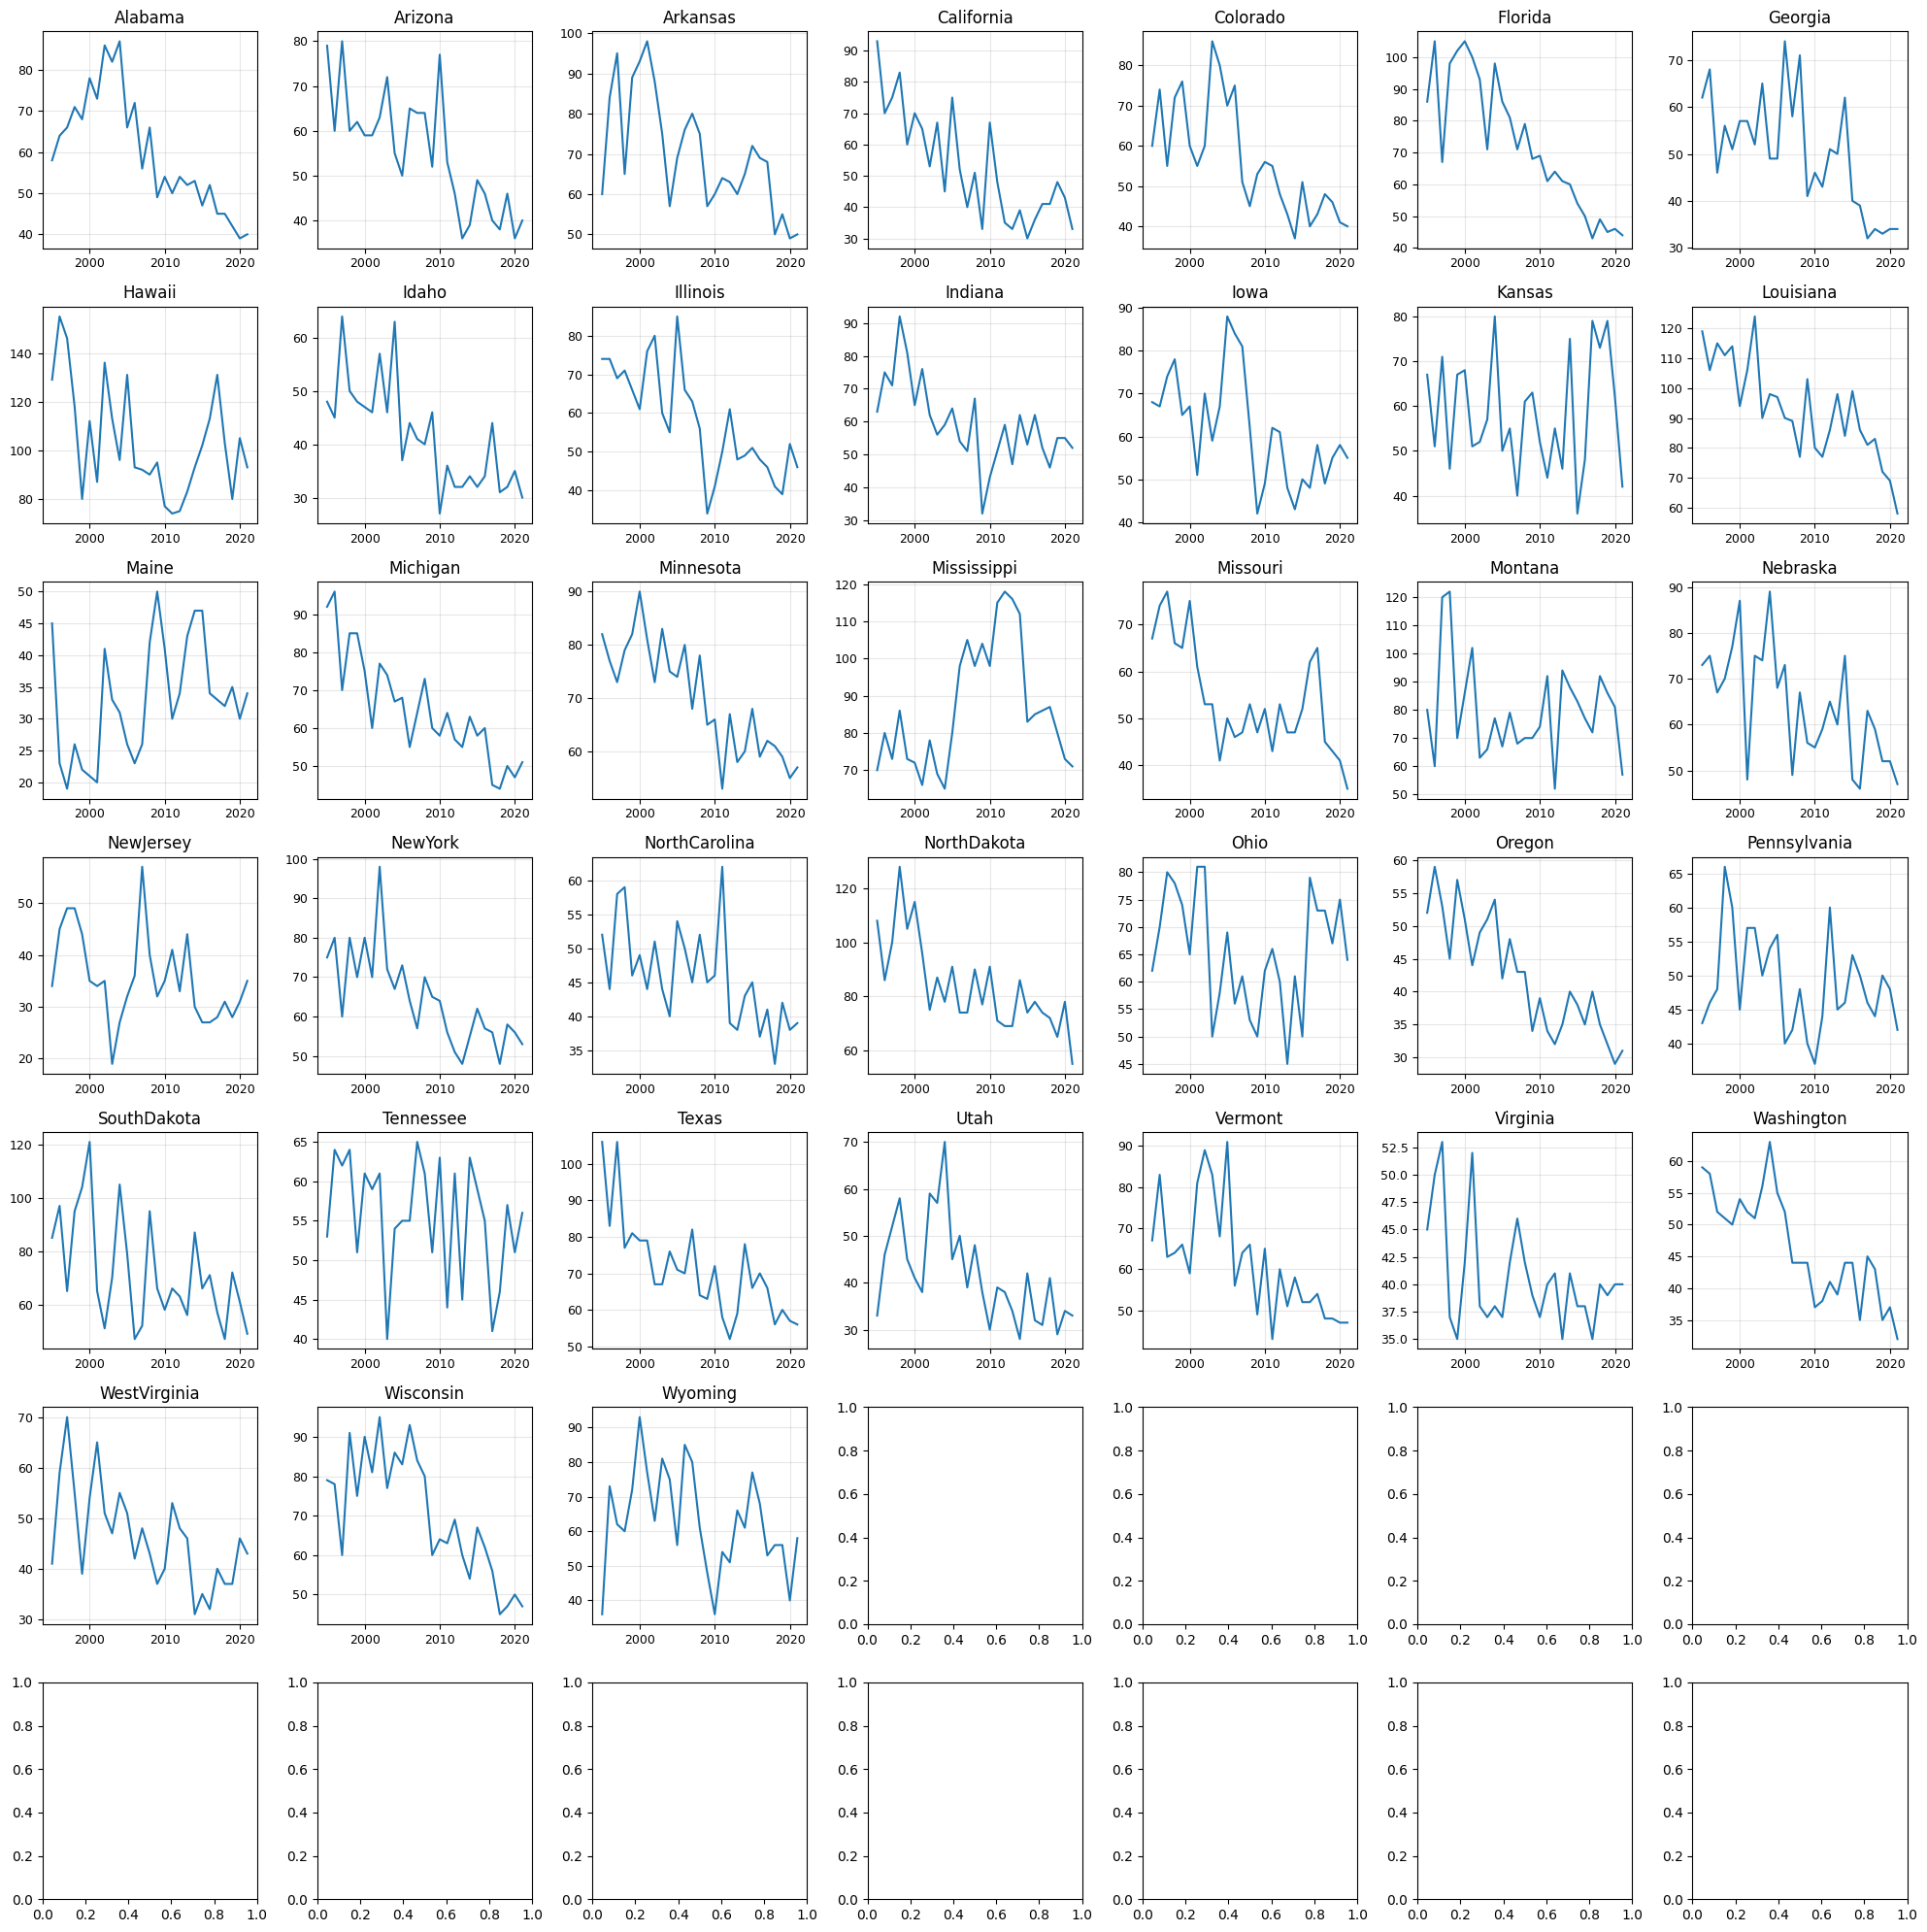

In [ ]:
utils.plot_all(honey_production_df, "state", "year", "yield_per_colony")

### Production Trend Prediction

0.8217742830203364


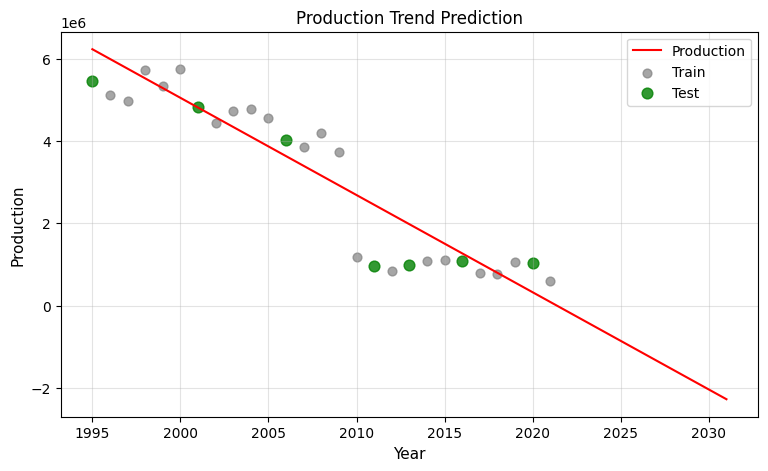

In [10]:
#setting up data
years = honey_production_df['year'].unique()
production_means = honey_production_df.groupby("year")["production"].mean()

#preparing the model
X_train, X_test, y_train, y_test = train_test_split(years.reshape(-1,1), 
                                                    production_means, 
                                                    test_size=0.25,
                                                    random_state=30)
model= LinearRegression()
model.fit(X = X_train, y = y_train)
print(model.score(X_test, y_test))

#setting up the data for predictions
future_years = np.arange(2022, 2032)
years = np.concatenate([years,future_years])
y_pred = model.predict(years.reshape(-1, 1))

#plotting the results
plt.figure(figsize=(9, 5))
plt.plot(years, y_pred, color="red", label="Production")
plt.scatter(X_train, y_train, color="grey", s=40, alpha=0.7, label="Train")
plt.scatter(X_test, y_test, color="green", s=60, alpha=0.8, label="Test")
plt.xlabel("Year", fontsize = 11)
plt.ylabel("Production", fontsize = 11)
plt.title("Production Trend Prediction")
plt.legend()
plt.grid(True, alpha=0.35)
plt.show()

### Price analysis

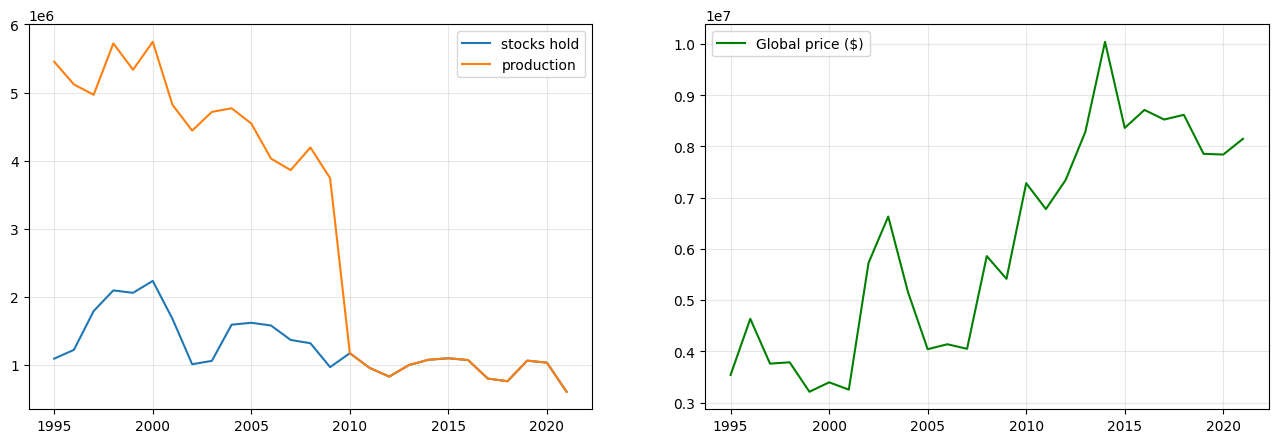

In [51]:
figure = plt.figure(figsize=(16,5))
plot1 = figure.add_subplot(1,2,1)
plot2 = figure.add_subplot(1,2,2)
plot1.plot(honey_production_df.year.unique(), honey_production_df.groupby("year")["stocks"].mean(), label = "stocks hold")
plot1.plot(honey_production_df.year.unique(), honey_production_df.groupby("year")["production"].mean(), label = "production")
plot2.plot(honey_production_df.year.unique(), honey_production_df.groupby("year")["value_of_production"].mean(), label = "Global price ($)", color = "green")
plot1.legend()
plot2.legend()
plot1.grid(alpha = 0.3)
plot2.grid(alpha = 0.3)

### Price trend Prediction 

0.7937643373061338


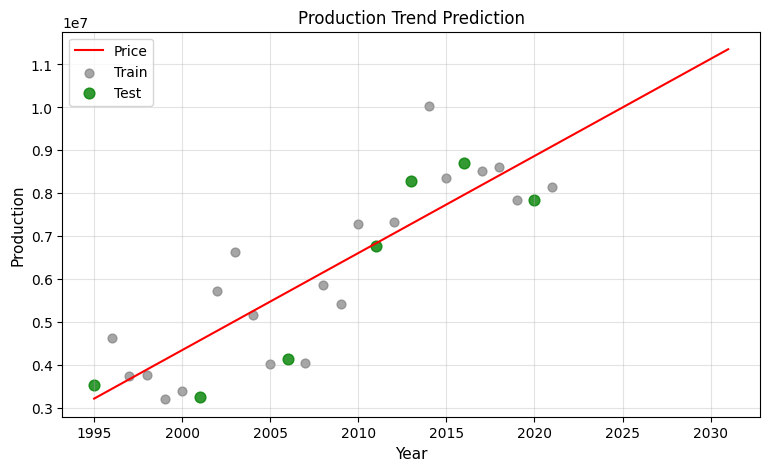

In [52]:
#setting up data
years = honey_production_df['year'].unique()
production_means = honey_production_df.groupby("year")["value_of_production"].mean()

#preparing the model
X_train, X_test, y_train, y_test = train_test_split(years.reshape(-1,1), 
                                                    production_means, 
                                                    test_size=0.25,
                                                    random_state=30)
model= LinearRegression()
model.fit(X = X_train, y = y_train)
print(model.score(X_test, y_test))

#setting up the data for predictions
future_years = np.arange(2022, 2032)
years = np.concatenate([years,future_years])
y_pred = model.predict(years.reshape(-1, 1))

#plotting the results
plt.figure(figsize=(9, 5))
plt.plot(years, y_pred, color="red", label="Price")
plt.scatter(X_train, y_train, color="grey", s=40, alpha=0.7, label="Train")
plt.scatter(X_test, y_test, color="green", s=60, alpha=0.8, label="Test")
plt.xlabel("Year", fontsize = 11)
plt.ylabel("Production", fontsize = 11)
plt.title("Production Trend Prediction")
plt.legend()
plt.grid(True, alpha=0.35)
plt.show()

## Part 2: Apistox 

In [13]:
utils.EDA(apistox_df, head = 7)

##-------------- INFO ------------------------------##

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1035 entries, 0 to 1034
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   name                1035 non-null   object
 1   CID                 1035 non-null   int64 
 2   CAS                 1035 non-null   object
 3   SMILES              1035 non-null   object
 4   source              1035 non-null   object
 5   year                1035 non-null   int64 
 6   toxicity_type       1035 non-null   object
 7   herbicide           1035 non-null   int64 
 8   fungicide           1035 non-null   int64 
 9   insecticide         1035 non-null   int64 
 10  other_agrochemical  1035 non-null   int64 
 11  label               1035 non-null   int64 
 12  ppdb_level          1035 non-null   int64 
dtypes: int64(8), object(5)
memory usage: 105.2+ KB


##-------------- DESCRIBE --------------------------##
        

### Further setup

In [3]:
#the following row alone can be of interest
#pesticide_usage_df = utils.load_pesticide_usage_datasets()

pesticide_usage_df = utils.apistox_support_setup()

apistox_complete_df = apistox_df.merge(pesticide_usage_df)
apistox_complete_df.drop(["name", "source", "SMILES", "CID", "year"], axis = 1, inplace=True)
apistox_complete_df.columns = apistox_complete_df.columns.map(str.upper)
apistox_complete_df

 pesticide_usage_df (107742, 6) : Done! 



,CAS,TOXICITY_TYPE,HERBICIDE,FUNGICIDE,INSECTICIDE,OTHER_AGROCHEMICAL,LABEL,PPDB_LEVEL,COMPOUND,YEAR,STATE_NAME
0,63-25-2,Contact,0,0,1,0,1,2,CARBARYL,2019,ALABAMA
1,63-25-2,Contact,0,0,1,0,1,2,CARBARYL,2019,ARIZONA
2,63-25-2,Contact,0,0,1,0,1,2,CARBARYL,2019,CALIFORNIA
3,63-25-2,Contact,0,0,1,0,1,2,CARBARYL,2019,CONNECTICUT
4,63-25-2,Contact,0,0,1,0,1,2,CARBARYL,2019,FLORIDA
...,...,...,...,...,...,...,...,...,...,...,...
1795,1072957-71-1,Contact,0,1,0,0,0,1,BENZOVINDIFLUPYR,2019,VIRGINIA
1796,1072957-71-1,Contact,0,1,0,0,0,1,BENZOVINDIFLUPYR,2019,WASHINGTON
1797,1072957-71-1,Contact,0,1,0,0,0,1,BENZOVINDIFLUPYR,2019,WEST VIRGINIA
1798,1072957-71-1,Contact,0,1,0,0,0,1,BENZOVINDIFLUPYR,2019,WISCONSIN


### Apistox analysis

In [4]:
utils.EDA(apistox_complete_df)

apistox_complete_df_copy = apistox_complete_df.copy()

##-------------- INFO ------------------------------##

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1800 entries, 0 to 1799
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   CAS                 1800 non-null   object
 1   TOXICITY_TYPE       1800 non-null   object
 2   HERBICIDE           1800 non-null   int64 
 3   FUNGICIDE           1800 non-null   int64 
 4   INSECTICIDE         1800 non-null   int64 
 5   OTHER_AGROCHEMICAL  1800 non-null   int64 
 6   LABEL               1800 non-null   int64 
 7   PPDB_LEVEL          1800 non-null   int64 
 8   COMPOUND            1800 non-null   object
 9   YEAR                1800 non-null   int64 
 10  STATE_NAME          1800 non-null   object
dtypes: int64(7), object(4)
memory usage: 154.8+ KB


##-------------- DESCRIBE --------------------------##
          HERBICIDE    FUNGICIDE  INSECTICIDE  OTHER_AGROCHEMICAL        LABEL  \
count  1800.000000  18

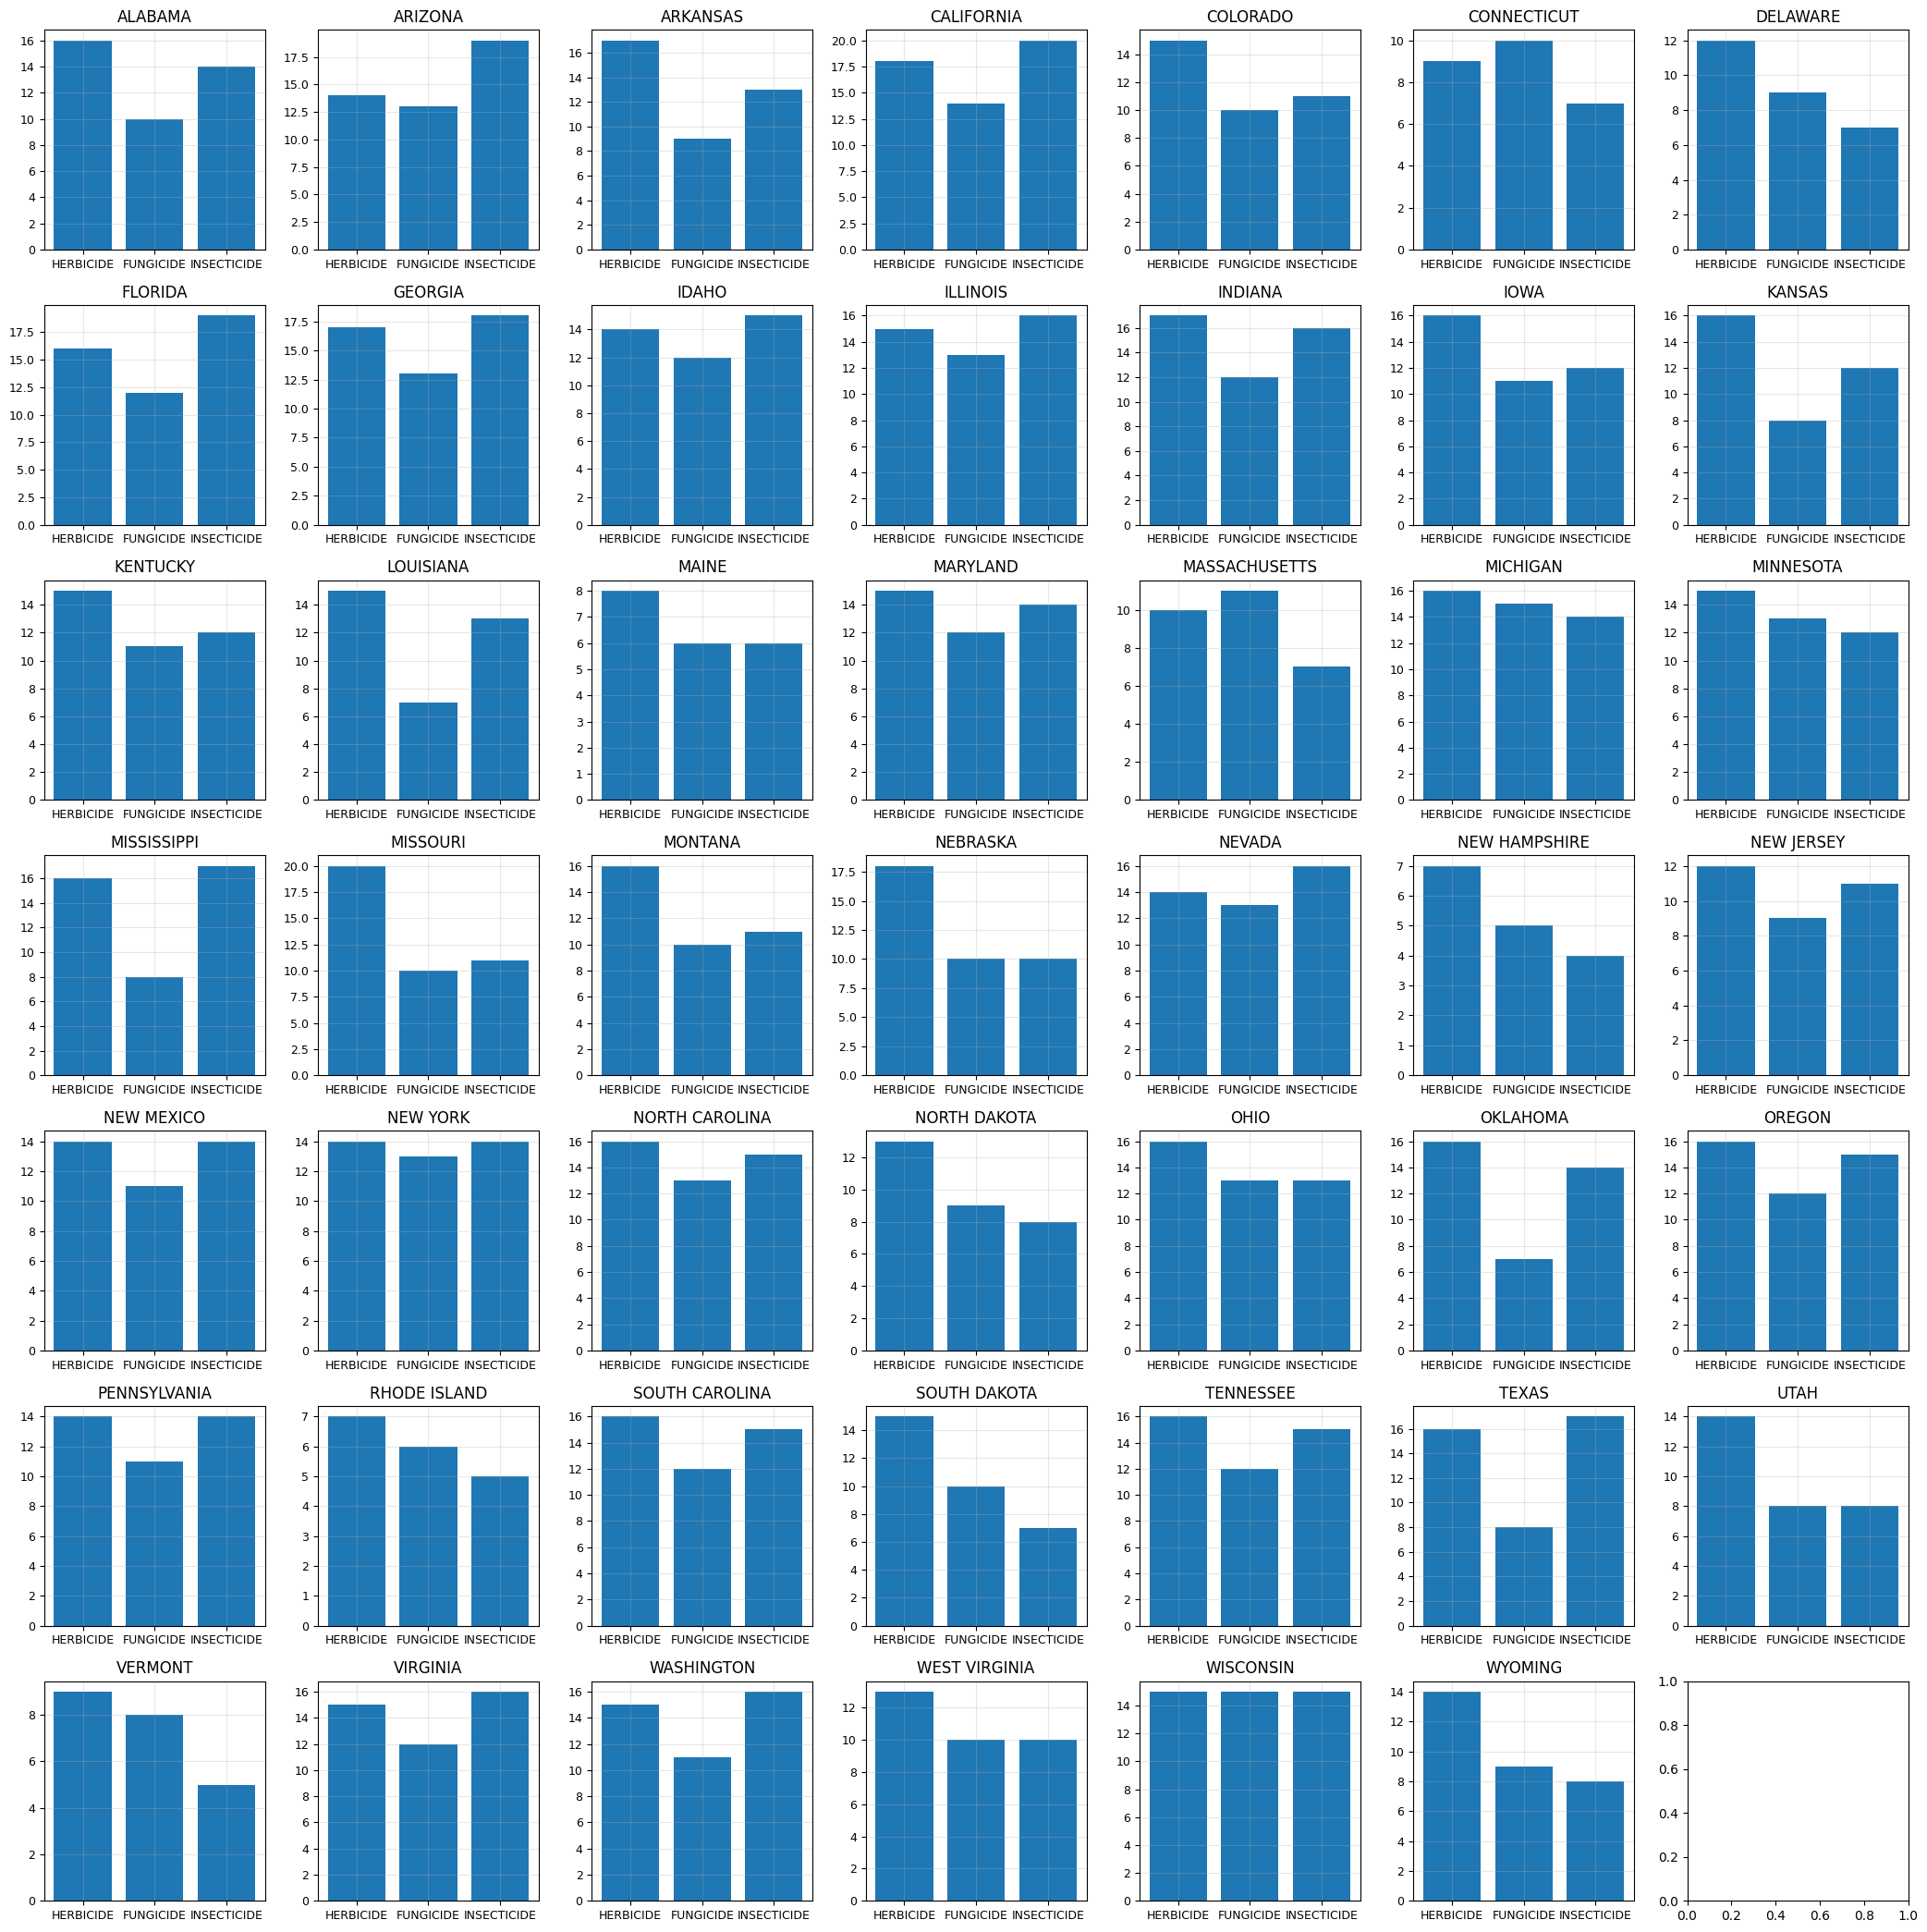

In [5]:
apistox_chems = apistox_complete_df.groupby(["STATE_NAME"])[["HERBICIDE", "FUNGICIDE", "INSECTICIDE"]].sum()

size = int(np.ceil(np.sqrt(len(apistox_chems.index))))
_, axes = plt.subplots(size, size, figsize =(21,21))

for index, element in enumerate(apistox_chems.index):
    bar = axes[int(index/size),index%size]
    bar.bar(apistox_chems.columns,  apistox_chems.loc[element].values.flatten())
    bar.set_title(str(element))
    bar.tick_params(axis ="both", labelsize = 9)
    bar.grid(alpha =0.3)
plt.tight_layout()


#POTREI: passare il df come primo, by come argomento del group, x come colonna/riga o array di labels, y come colonne del grouped
# il metodo fa bar di tutte le colonne numeriche associate al grouped

#TODO: rimpiazzare questa procedura con un metodo in utils
#apistox_chems = apistox_complete_df.groupby(["STATE_NAME"]).sum()
#utils.bar_all(apistox_chems,3, apistox_chems.columns,  )

### Apistox Classification

In [34]:
X = pd.get_dummies(apistox_complete_df[["HERBICIDE", "FUNGICIDE", "INSECTICIDE", "TOXICITY_TYPE"]])
first_target = apistox_complete_df.PPDB_LEVEL
second_target = apistox_complete_df.LABEL
random_forest = RandomForestClassifier(n_estimators=750, random_state=42)

#doing random forest to establish first what is mostly important when defining the level of toxicity
X_train, X_test, y_train, y_test = train_test_split(X,first_target, test_size=0.2, random_state=42)
random_forest.fit(X_train, y_train)

y_pred = random_forest.predict(X_test)
score = accuracy_score(y_true=y_test, y_pred=y_pred)

print("First score: ", score , "\n")
print("PPDB level determination")
print(pd.DataFrame({
    'Features': X.columns,
    'Weight %': random_forest.feature_importances_
}))

print("\n---------------------------------------------\n")
#Repeating the process to establish what defines a compound as harmful or not (label)
X_train, X_test, y_train, y_test = train_test_split(X,second_target, test_size=0.2, random_state=42)
random_forest.fit(X_train, y_train)

y_pred = random_forest.predict(X_test)
score = accuracy_score(y_true=y_test, y_pred=y_pred)

print("Second score: ", score , "\n")
print("Harm label determination")
print(pd.DataFrame({
    'Features': X.columns,
    'Weight %': random_forest.feature_importances_
}))

First score:  0.7444444444444445 

PPDB level determination
                Features  Weight %
0              HERBICIDE  0.177301
1              FUNGICIDE  0.139658
2            INSECTICIDE  0.545071
3  TOXICITY_TYPE_Contact  0.065129
4     TOXICITY_TYPE_Oral  0.053529
5    TOXICITY_TYPE_Other  0.019312

---------------------------------------------

Second score:  0.9611111111111111 

Harm label determination
                Features  Weight %
0              HERBICIDE  0.182152
1              FUNGICIDE  0.176910
2            INSECTICIDE  0.623404
3  TOXICITY_TYPE_Contact  0.005469
4     TOXICITY_TYPE_Oral  0.005337
5    TOXICITY_TYPE_Other  0.006728


## Part 3: Weather Effects on Bees Health
